# Task 3: Helper notebook for loading the data and saving the predictions

In [2]:
import pickle
import gzip
import numpy as np
from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import cv2
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.filters import threshold_otsu, threshold_yen, threshold_multiotsu
from skimage.feature import canny



import os

### Helper functions

In [2]:
def load_zipped_pickle(filename):
    with gzip.open(filename, 'rb') as f:
        loaded_object = pickle.load(f)
        return loaded_object

In [3]:
def save_zipped_pickle(obj, filename):
    with gzip.open(filename, 'wb') as f:
        pickle.dump(obj, f, 2)

### Load data, make predictions and save prediction in correct format

In [203]:
# load data
train_data = load_zipped_pickle("train.pkl")
test_data = load_zipped_pickle("test.pkl")
#samples = load_zipped_pickle("sample.pkl")


In [7]:
#As the data is really small, we repeat it to have more samples for the batches in ImageDataGenerator
train_data = np.repeat(train_data, 5, axis=0)
# test_data = np.repeat(test_data, 5, axis=0)

In [5]:
# puts images in the right shape
def reshape_data(data, x, y):
    return cv2.resize(data, dsize=(x, y), interpolation=cv2.INTER_CUBIC)

In [21]:
# add different channels

# denoise channel
def denoise(data):
    return denoise_nl_means(data, h=0.8 * estimate_sigma(data), fast_mode=True, patch_size=5, patch_distance=6)

# blur channel
def blur(data, mode="median"):
    if mode == "median":
        return cv2.medianBlur(data, 3)
    elif mode == "gauss":
        return cv2.GaussianBlur(data, (3,3), 1)

# threshold channel
def myThreshold(data, method='otsu', class_nb = 0):
    if method == 'otsu':
        thresh_val = threshold_otsu(data)
        mask = (data > thresh_val).astype(np.float32)
    elif method == 'yen':
        thresh_val = threshold_yen(data)
        mask = (data > thresh_val).astype(np.float32)
    elif method == 'multiotsu':
        # 3 classes
        thresholds = threshold_multiotsu(data, classes=3)
        mask = np.digitize(data, bins=thresholds)
        mask = (mask == class_nb).astype(np.float32)
    return mask


# edge detection channel
def edge(data, sigma=1.0):
    edges = canny(data, sigma=sigma).astype(np.float32)
    return edges


def preprocess_images(images, labels,
                      add_denoised=True, 
                      add_blurred=True, 
                      blur_mode='median', 
                      add_threshold=True, 
                      threshold_method='otsu',
                      class_nb=0,
                      add_edges=True):

    images = np.asarray(images, dtype=np.float32)

    channels = [images]  # original images are one channel then add others
    stacked_labels = [labels]

    if add_denoised:
        denoised_imgs = np.stack([denoise(img) for img in images], axis=0)
        channels.append(denoised_imgs)
        stacked_labels.append(labels)

    if add_blurred:
        blurred_imgs = np.stack([blur(img, mode=blur_mode) for img in images], axis=0)
        channels.append(blurred_imgs)
        stacked_labels.append(labels)


    if add_threshold:
        threshold_imgs = np.stack([myThreshold(img, method=threshold_method, class_nb=class_nb) for img in images], axis=0)
        channels.append(threshold_imgs)
        stacked_labels.append(labels)

    if add_edges:
        edge_imgs = np.stack([edge(img) for img in images], axis=0)
        channels.append(edge_imgs)
        stacked_labels.append(labels)

    combined = np.stack(channels, axis=-1)
    stacked_labels = np.stack(stacked_labels, axis=-1)

    return combined, stacked_labels

In [3]:
from tqdm import tqdm
import matplotlib.pyplot as plt
image_size = 128

def preprocess_train_data(data):
    video_frames = []
    mask_frames = []
    names = []
    boxes = []
    for item in tqdm(data):
        video = item['video']
        name = item['name']
        box = item['box']
        height, width, n_frames = video.shape
        mask = np.zeros((height, width, n_frames), dtype=np.bool)
        for frame in item['frames']:
            mask[:, :, frame] = item['label'][:, :, frame]
            video_frame = video[:, :, frame].astype(np.float32) / 255.0 #we scale down images
            video_frame = reshape_data(video_frame, image_size, image_size)
            mask_frame = mask[:, :, frame].astype(np.uint8)
            mask_frame = reshape_data(mask_frame, image_size, image_size)

            #video_frame = np.expand_dims(video_frame, axis=0) #put in the format (1, image_size, image_size)

            #mask_frame = np.expand_dims(mask_frame, axis=0)
            
            video_frames.append(video_frame)
            mask_frames.append(mask_frame)
            #They both appear 3 times in total (3 frames), to get the same size of all lists
            names.append(name)
            boxes.append(box)


    boxes = [np.array(box).astype(np.uint8) for box in boxes]
    return names, video_frames, mask_frames, boxes

In [189]:
names, videos, masks, boxes = preprocess_train_data(train_data)
videos, masks = preprocess_images(videos, masks, add_denoised=True, add_blurred=True, blur_mode='median', add_threshold=True, threshold_method='otsu', class_nb=0, add_edges=True)
#test_names, test_videos = preprocess_test_data(test_data)

# IMPORTANTTTT
# might want to add different channels for the videos, e.g. optical flow, or blurred/denoised images
# and so need to stack the masks as many times as the number of channels
print(videos[0].shape, masks[0].shape, len(boxes))

  0%|          | 0/65 [00:00<?, ?it/s]C:\Users\tzamb\AppData\Local\Temp\ipykernel_18580\650209450.py:15: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros((height, width, n_frames), dtype=np.bool)
100%|██████████| 65/65 [00:02<00:00, 28.31it/s] 


(128, 128, 5) (128, 128, 5) 195


In [12]:
seed = 42
batch_size = 8  #hyperparameter to optimise


#We do data augmentation, to facilitate our life we use the ImageDataGenerator from Keras
datagen_video = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='constant')
#We dont flip because the right mitral valve is going to be on the right and don't want to confuse model
#Might want to check the hyperparameters of the ImageDataGenerator

datagen_mask = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='constant')


#X is videos, Y is masks (labels)
def generate_data(X_train, y_train, X_valid, y_valid, batch_size):
    generated_X_train = datagen_video.flow(X_train, batch_size=batch_size, seed=seed)
    generated_y_train = datagen_mask.flow(y_train, batch_size=batch_size, seed=seed)
    generated_X_valid = datagen_video.flow(X_valid, batch_size=batch_size, seed=seed)
    generated_y_valid = datagen_mask.flow(y_valid, batch_size=batch_size, seed=seed)
    
    # we create "tuples" of the videos and masks
    def zip_generated_data(generated_X, generated_y):
        for X, y in zip(generated_X, generated_y):
            yield (X, y)
    
    generated_data_train = zip_generated_data(generated_X_train, generated_y_train)
    generated_data_valid = zip_generated_data(generated_X_valid, generated_y_valid)

    return generated_data_train, generated_data_valid


In [13]:
#We split the data into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(videos, masks, test_size=0.2, random_state=42)
print(X_train.shape)
print(len(X_train), len(X_valid), len(y_train), len(y_valid))

(780, 128, 128, 5)
780 195 780 195


In [14]:
#We generate the data
generated_data_train, generated_data_valid = generate_data(X_train, y_train, X_valid, y_valid, batch_size=batch_size)
print(generated_data_train.__next__()[0][0].shape)

C:\Users\tzamb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\keras\preprocessing\image.py:766: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_last" (channels on axis 3), i.e. expected either 1, 3, or 4 channels on axis 3. However, it was passed an array with shape (780, 128, 128, 5) (5 channels).
  warnings.warn(
C:\Users\tzamb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\keras\preprocessing\image.py:766: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_last" (channels on axis 3), i.e. expected either 1, 3, or 4 channels on axis 3. However, it was passed an array with shape (195, 128, 128, 5) (5 channels).
  warnings.warn(


(128, 128, 5)


In [15]:
# num_channels = img.shape[-1]

# plt.figure(figsize=(15, 3))  # Adjust figure size as needed
# for i in range(num_channels):
#     plt.subplot(1, num_channels, i + 1)
#     plt.imshow(img[:,:,i], cmap='gray')
#     plt.title(f'Channel {i}')
#     plt.axis('off')

# plt.tight_layout()
# plt.show()

In [16]:
#Now need to develope the model


In [12]:
import segmentation_models_pytorch as smp
import torch
from torch.utils.data import DataLoader, Dataset
from torch import nn, optim


In [24]:
def combined_bce_dice_loss(preds, targets, alpha=0.5, beta=0.5, eps=1e-6):
    bce = torch.nn.functional.binary_cross_entropy(preds, targets)
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()
    dice = 1 - (2.0 * intersection + eps) / (union + eps)
    return alpha * bce + beta * dice

# Training function
def train_model(model, train_generator, valid_generator, steps_per_epoch, validation_steps, num_epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    best_loss = float("inf")

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        
        # Limit the training generator to steps_per_epoch batches
        for step in range(steps_per_epoch):
            videos, masks = next(train_generator)  # Get the next batch
            videos = torch.tensor(videos).permute(0, 3, 1, 2).to(device)
            masks = torch.tensor(masks).unsqueeze(1).to(device)
            masks = masks[..., 0]

            optimizer.zero_grad()
            outputs = model(videos)
            outputs = torch.sigmoid(outputs)
            loss = combined_bce_dice_loss(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * videos.shape[0]

        train_loss /= steps_per_epoch * videos.shape[0]

        model.eval()
        valid_loss = 0.0

        # Limit the validation generator to validation_steps batches
        with torch.no_grad():
            for step in range(validation_steps):
                videos, masks = next(valid_generator)
                videos = torch.tensor(videos).permute(0, 3, 1, 2).to(device)
                masks = torch.tensor(masks).unsqueeze(1).to(device)
                masks = masks[..., 0]

                outputs = model(videos)
                outputs = torch.sigmoid(outputs)
                loss = combined_bce_dice_loss(outputs, masks)

                valid_loss += loss.item() * videos.shape[0]

        valid_loss /= validation_steps * videos.shape[0]

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}")

        if valid_loss < best_loss:
            best_loss = valid_loss
            torch.save(model.state_dict(), "best_model.pth")

    return model


In [13]:
class UNetPlusPlus(nn.Module):
    def __init__(self, in_channels, out_channels):  # Fix the typo here
        super(UNetPlusPlus, self).__init__()
        self.model = smp.UnetPlusPlus(
            encoder_name="resnet34",  # Choose a ResNet backbone
            encoder_weights="imagenet",  # Pre-trained on ImageNet
            in_channels=in_channels,
            classes=out_channels
        )

    def forward(self, x):
        return self.model(x)
    



In [27]:
model = UNetPlusPlus(in_channels=5, out_channels=1)

steps_per_epoch = len(X_train) // batch_size
validation_steps = len(X_valid) // batch_size

trained_model = train_model(
    model,
    train_generator=generated_data_train,
    valid_generator=generated_data_valid,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    num_epochs=30
)

cuda
Epoch 1/30, Train Loss: 0.6916, Valid Loss: 0.6020
Epoch 2/30, Train Loss: 0.5767, Valid Loss: 0.5339
Epoch 3/30, Train Loss: 0.5175, Valid Loss: 0.4820
Epoch 4/30, Train Loss: 0.4662, Valid Loss: 0.4323
Epoch 5/30, Train Loss: 0.4118, Valid Loss: 0.3764
Epoch 6/30, Train Loss: 0.3530, Valid Loss: 0.3134
Epoch 7/30, Train Loss: 0.2869, Valid Loss: 0.2552
Epoch 8/30, Train Loss: 0.2306, Valid Loss: 0.2061
Epoch 9/30, Train Loss: 0.1926, Valid Loss: 0.1779
Epoch 10/30, Train Loss: 0.1666, Valid Loss: 0.1637
Epoch 11/30, Train Loss: 0.1510, Valid Loss: 0.1462
Epoch 12/30, Train Loss: 0.1405, Valid Loss: 0.1388
Epoch 13/30, Train Loss: 0.1334, Valid Loss: 0.1321
Epoch 14/30, Train Loss: 0.1264, Valid Loss: 0.3404
Epoch 15/30, Train Loss: 0.1216, Valid Loss: 0.1257
Epoch 16/30, Train Loss: 0.1159, Valid Loss: 0.1212
Epoch 17/30, Train Loss: 0.1133, Valid Loss: 0.1164
Epoch 18/30, Train Loss: 0.1104, Valid Loss: 0.1127
Epoch 19/30, Train Loss: 0.1080, Valid Loss: 0.1108
Epoch 20/30, Tra

In [118]:
x_valid_sample, y_valid_sample = next(generated_data_valid)  # Get one batch from the generator


0


C:\Users\tzamb\AppData\Local\Temp\ipykernel_16236\3833868649.py:41: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(5, num_samples_to_plot, num_samples_to_plot + i + 1)
C:\Users\tzamb\AppData\Local\Temp\ipykernel_16236\3833868649.py:58: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout()


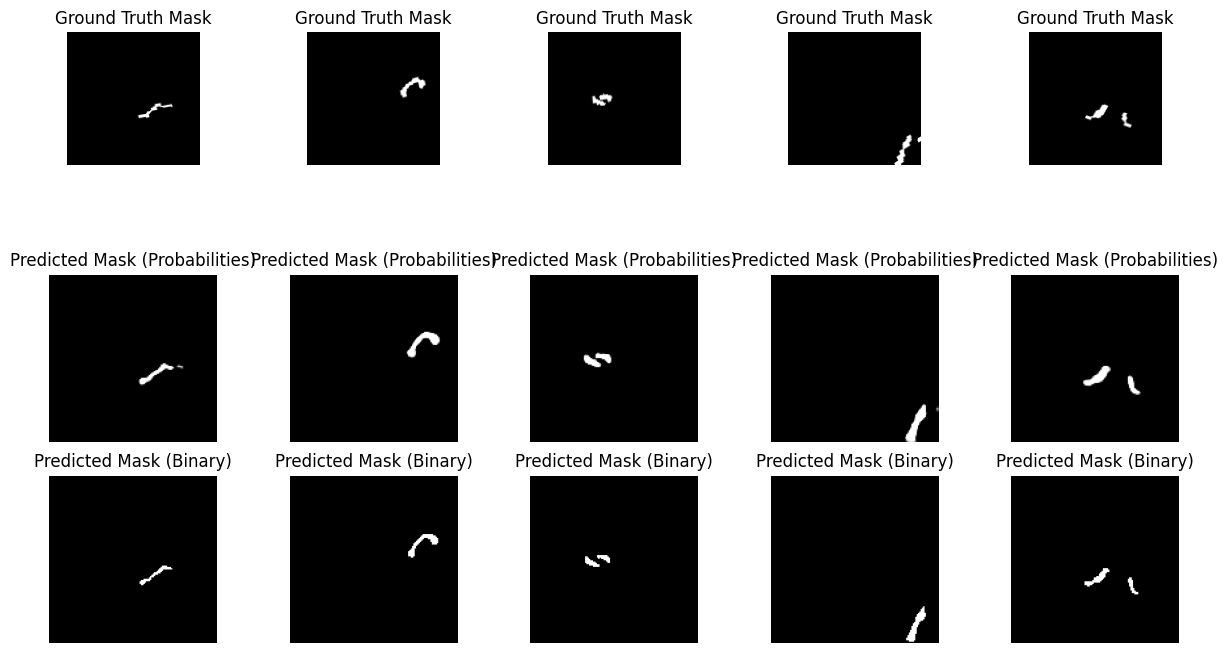

In [126]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Generate predictions on the validation data

# Convert validation images to a PyTorch tensor
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_valid_sample_tensor = torch.tensor(x_valid_sample).permute(0, 3, 1, 2).to(device)  # (B, C, H, W)

# Move the model to evaluation mode
trained_model.eval()

# Predict masks
with torch.no_grad():
    predicted_masks = trained_model(x_valid_sample_tensor)
    predicted_masks = torch.sigmoid(predicted_masks).cpu().numpy()  # Convert to NumPy (Probabilities)
    print(len(predicted_masks[predicted_masks>0.9999999]))


# Apply thresholding
threshold = 0.99
binary_predicted_masks = (predicted_masks > threshold).astype(np.uint8)  # Convert to binary

# Remove channel dimension (if present) for visualization
predicted_masks = np.squeeze(predicted_masks, axis=1) if predicted_masks.shape[1] == 1 else predicted_masks
binary_predicted_masks = np.squeeze(binary_predicted_masks, axis=1) if binary_predicted_masks.shape[1] == 1 else binary_predicted_masks
y_valid_sample = np.squeeze(y_valid_sample, axis=-1) if y_valid_sample.shape[-1] == 1 else y_valid_sample
# Visualize a few examples
num_samples_to_plot = min(5, x_valid_sample.shape[0])  # Plot up to 5 samples
plt.figure(figsize=(15, 10))

for i in range(num_samples_to_plot):
    # Plot the original image (first channel assumed as grayscale)
    plt.subplot(4, num_samples_to_plot, i + 1)
    plt.imshow(x_valid_sample[i, :, :, 0], cmap="gray")
    plt.title("Original Image")
    plt.axis("off")
    
    # Plot the ground truth mask
    plt.subplot(5, num_samples_to_plot, num_samples_to_plot + i + 1)
    plt.imshow(y_valid_sample[i][..., 0], cmap="gray")  # Plot ground truth mask
    plt.title("Ground Truth Mask")
    plt.axis("off")
    
    # Plot the predicted mask (probabilities)
    plt.subplot(4, num_samples_to_plot, 2 * num_samples_to_plot + i + 1)
    plt.imshow(predicted_masks[i], cmap="gray")
    plt.title("Predicted Mask (Probabilities)")
    plt.axis("off")
    
    # Plot the binary predicted mask (after thresholding)
    plt.subplot(4, num_samples_to_plot, 3 * num_samples_to_plot + i + 1)
    plt.imshow(binary_predicted_masks[i], cmap="gray")
    plt.title("Predicted Mask (Binary)")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [6]:
def preprocess_test_data(data):
    video_frames = []
    names = []
    for item in tqdm(data):
        video = item['video']
        video = video.astype(np.float32).transpose((2, 0, 1))
        video = np.expand_dims(video, axis=3)
        video_frames += list(video)
        names += [item['name'] for _ in video]
    return names, video_frames

In [22]:
def preprocess_test(images,
                      add_denoised=True, 
                      add_blurred=True, 
                      blur_mode='median', 
                      add_threshold=True, 
                      threshold_method='otsu',
                      class_nb=0,
                      add_edges=True):
    
    images = np.asarray(images, dtype=np.float32)

    channels = [images]  # original images are one channel then add others
    if add_denoised:
        denoised_imgs = np.stack([denoise(img) for img in images], axis=0)
        channels.append(denoised_imgs)

    if add_blurred:
        blurred_imgs = np.stack([blur(img, mode=blur_mode) for img in images], axis=0)
        channels.append(blurred_imgs)


    if add_threshold:
        threshold_imgs = np.stack([myThreshold(img, method=threshold_method, class_nb=class_nb) for img in images], axis=0)
        channels.append(threshold_imgs)

    if add_edges:
        edge_imgs = np.stack([edge(img) for img in images], axis=0)
        channels.append(edge_imgs)

    combined = np.stack(channels, axis=-1)

    return combined

In [44]:
test_names, X_test  = preprocess_test_data(test_data)

100%|██████████| 20/20 [00:02<00:00,  8.76it/s]


In [45]:
original_sizes = []
for item in X_test:
    original_sizes.append((item.shape[0], item.shape[1]))


In [46]:
unrolled_videos = []

for video in X_test:
    unrolled_video = np.hstack([video[:, :, frame].astype(np.float32)/255.0 for frame in range(video.shape[2])])  # Unroll each video
    #we scaled down images
    unrolled_videos.append(reshape_data(unrolled_video, image_size, image_size)) 
print(len(unrolled_videos), unrolled_videos[0].shape)
X_test = preprocess_test(unrolled_videos, add_denoised=True, add_blurred=True, blur_mode='median', add_threshold=True, threshold_method='otsu', class_nb=0, add_edges=True)
print(X_test[0].shape)

1507 (128, 128)
(128, 128, 5)


### From the flattented array, retrieve indices and length for submission format

In [227]:
def get_sequences(arr):
    first_indices, last_indices, lengths = [], [], []
    n, i = len(arr), 0
    arr = np.array([0] + list(arr) + [0], dtype=np.int16)  # Cast to int16 to avoid overflow

    for index, value in enumerate(arr[:-1]):
        if arr[index+1]-arr[index] == 1:
            first_indices.append(index)
        if arr[index+1]-arr[index] == -1:
            last_indices.append(index)
    lengths = list(np.array(last_indices)-np.array(first_indices))
    return first_indices, lengths

In [228]:
a, b = get_sequences([1,1,1,0,0,1,1,0,0,1,0])
print(a)
print(b)

[0, 5, 9]
[3, 2, 1]


### Create .csv in submission format

In [4]:
import numpy as np
import pandas as pd
from skimage.transform import resize


def create_submission(model, X_test, original_sizes, test_data, threshold=0.5, submission_file="submission.csv"):
    """
    Generates a submission file for the segmentation task.

    Parameters:
    - model: Trained model for predictions
    - X_test: List of test videos preprocessed for the model
    - original_sizes: List of tuples indicating the original size of each test video
    - test_data: List of strings (video names or filenames) corresponding to test data
    - threshold: Threshold to binarize the predictions
    - submission_file: Name of the output CSV file
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()  # Set the model to evaluation mode

    video_masks = {}  # Dictionary to store concatenated masks for each video

    # Predict masks
    with torch.no_grad():
        for i, video in enumerate(X_test):
            # Extract the base name (e.g., video name) from test_data
            name = test_data[i].split('.')[0]  # Assuming filenames have extensions like .png or .jpg

            # Predict the mask for the video
            video_tensor = torch.tensor(video).permute(2, 0, 1).unsqueeze(0).to(device)  # Shape (1, C, H, W)
            output = model(video_tensor)  # Get the model output
            output = torch.sigmoid(output)  # Apply sigmoid to get probabilities

            # Threshold and resize the mask back to original size
            binary_mask = (output.squeeze().cpu().numpy() > threshold).astype(np.uint8)
            resized_mask = torch.nn.functional.interpolate(
                torch.tensor(binary_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to('cuda'),
                size=original_sizes[i],
                mode="nearest"
            ).squeeze().to('cpu').numpy().astype(np.uint8)

            # Flatten the resized mask
            flattened_mask = resized_mask.flatten()

            # Concatenate masks for the same video
            if name not in video_masks:
                video_masks[name] = flattened_mask
            else:
                video_masks[name] = np.concatenate((video_masks[name], flattened_mask))

    values = []
    ids = []  # List to store unique IDs

    # Process concatenated masks
    for name, concatenated_mask in video_masks.items():
        print(name, len(concatenated_mask), concatenated_mask.sum())

        # Get sequences of ones from the concatenated mask
        first_indices, lengths = get_sequences(concatenated_mask)

        # Format the output for this mask
        for start, length in zip(first_indices, lengths):
            values.append(f"[{start}, {length}]")
            ids.append(f"{name}_{len(ids)}")  # Generate a unique ID for each sequence

    # Create a DataFrame for submission
    submission_df = pd.DataFrame({"id": ids, "value": values})
    submission_df.to_csv(submission_file, index=False)
    print(f"Submission file saved as {submission_file}")


In [5]:
def generate_masks(model, X_test, original_sizes, test_data, threshold=0.5):
    """
    Generates segmentation masks for the test videos.

    Parameters:
    - model: Trained model for predictions
    - X_test: List of test videos preprocessed for the model
    - original_sizes: List of tuples indicating the original size of each test video
    - test_data: List of strings (video names or filenames) corresponding to test data
    - threshold: Threshold to binarize the predictions

    Returns:
    - masks: A dictionary with video names as keys and masks as values
    """
    from collections import defaultdict
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()  # Set the model to evaluation mode

    # Dictionary to store masks for each video name
    masks_accumulated = defaultdict(list)

    with torch.no_grad():
        for i, video in enumerate(X_test):
            # Get the video name (assumes filenames in test_data)
            name = test_data[i].split('.')[0]

            # Predict the mask for the video
            video_tensor = torch.tensor(video).permute(2, 0, 1).unsqueeze(0).to(device)  # Shape (1, C, H, W)
            output = model(video_tensor)  # Get the model output
            output = torch.sigmoid(output)  # Apply sigmoid to get probabilities

            # Threshold and resize the mask back to original size
            binary_mask = (output.squeeze().cpu().numpy() > threshold).astype(np.uint8)
            resized_mask = torch.nn.functional.interpolate(
                torch.tensor(binary_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to('cuda'),
                size=original_sizes[i],
                mode="nearest"
            ).squeeze().to('cpu').numpy().astype(np.uint8)

            # Add the resized mask to the corresponding video name
            masks_accumulated[name].append(resized_mask)

    # Pack accumulated masks back together
    masks = {}
    for name, frames in masks_accumulated.items():
        # Stack frames along the third axis (width, height, nb_frames)
        masks[name] = np.stack(frames, axis=-1)

    return masks


In [6]:
trained_model = UNetPlusPlus(in_channels=5, out_channels=1)

# Load the saved weights
trained_model.load_state_dict(torch.load("best_model.pth"))
# create_submission(trained_model, X_test, original_sizes, test_names, threshold=0.05, submission_file="submission_005.csv")

predicted_masks = generate_masks(trained_model, X_test, original_sizes, test_names, threshold=0.05)

NameError: name 'UNetPlusPlus' is not defined

In [77]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def play_video_with_mask(video, mask, output_file="animation.gif", fps=10):
    """
    Saves the video with the corresponding mask overlay as a GIF or video.

    Parameters:
    - video: A 3D numpy array (height, width, num_frames)
    - mask: A 3D numpy array (height, width, num_frames), binary mask
    - output_file: Name of the output file (e.g., 'animation.gif')
    - fps: Frames per second for the animation
    """
    # Validate input
    assert video.shape == mask.shape, "Video and mask must have the same shape."

    num_frames = video.shape[-1]

    # Create the figure and axis
    fig, ax = plt.subplots()
    fig.subplots_adjust(top=0.85)

    # Add a title
    ax.set_title("Video with Segmentation Mask")
    ax.axis("off")  # Turn off axes for better display

    # Placeholder for image and mask overlay
    img_display = ax.imshow(video[:, :, 0], cmap="gray", interpolation="nearest")
    mask_overlay = ax.imshow(mask[:, :, 0], cmap="Reds", alpha=0.5, interpolation="nearest")

    # Update function for the animation
    def update(frame):
        img_display.set_data(video[:, :, frame])
        mask_overlay.set_data(mask[:, :, frame])
        return img_display, mask_overlay

    # Create the animation
    anim = FuncAnimation(
        fig, update, frames=num_frames, interval=1000 // fps
    )

    # Save the animation as a GIF
    anim.save(output_file, writer=PillowWriter(fps=fps))
    print(f"Animation saved as {output_file}")



In [133]:
y = predicted_masks[test_data[14]['name']]
print(y.shape)

frames = [y[:, :, frame] for frame in range(y.shape[2])]  # Unroll each video
print(len(frames), frames[0].shape)
print(sum(frames[8].flatten()))


(707, 855, 39)
39 (707, 855)
1064


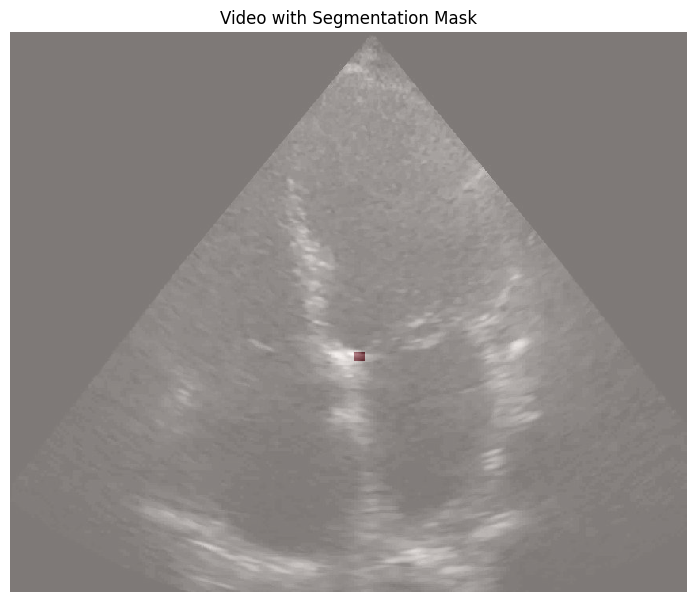

In [186]:
%matplotlib inline
i = 5
y = predicted_masks[test_data[14]['name']][:, :, i]
y = y.astype(np.uint8)
x = test_data[14]['video'][:, :, i]

plt.figure(figsize=(7.07, 8.55))

# Display the video frame
plt.imshow(x, cmap="gray", interpolation="nearest")

# Overlay the binary mask
plt.imshow(y, cmap="Reds", alpha=0.5, interpolation="nearest")  # Set alpha to blend the mask with the video

# Add a title and hide axes
plt.title("Video with Segmentation Mask")
plt.axis("off")  # Hide axes for better visualization

# Show the combined visualization
plt.tight_layout()
plt.show()


In [131]:
for i in range(20):
    play_video_with_mask(test_data[i]["video"], predicted_masks[test_data[i]['name']], output_file=f"animation{i}.gif", fps=15)

<IPython.core.display.Javascript object>

KeyboardInterrupt: 


**Postprocessing, not used for now**


In [ ]:
# postprocess the mask
from skimage.restoration import denoise_tv_chambolle
import cv2
import numpy as np

def anisotropic_diffusion(image, weight=0.1):
    """
    Applies anisotropic diffusion to smooth the image while preserving edges.
    """
    return denoise_tv_chambolle(image, weight=weight)

def apply_morphological_closing(binary_mask, kernel_size=3):
    """
    Applies morphological closing to fill small holes in the binary mask.
    """
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    closed_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    return closed_mask

def refine_with_bilateral_filter(image, mask, sigma_color=75, sigma_space=75):
    """
    Refines the mask using bilateral filtering to smooth while preserving edges.
    """
    # Convert mask to 8-bit and normalize
    mask = (mask * 255).astype(np.uint8)

    # Apply bilateral filter to the image
    refined_image = cv2.bilateralFilter(image, d=5, sigmaColor=sigma_color, sigmaSpace=sigma_space)

    # Threshold the refined image for binary mask
    _, refined_mask = cv2.threshold(refined_image, 128, 255, cv2.THRESH_BINARY)

    return refined_mask.astype(np.uint8)

def refine_with_grabcut(image, mask, iterations=5):
    """
    Refines the mask using OpenCV's GrabCut.
    """
    # Ensure the image is in 3-channel BGR format
    if len(image.shape) == 2:  # Grayscale
        image = (image * 255).astype(np.uint8)  # Scale image to 0-255
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    elif len(image.shape) == 3 and image.shape[-1] == 1:  # Single-channel with 3rd dim
        image = (image.squeeze() * 255).astype(np.uint8)
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    elif image.dtype != np.uint8:  # If not already 8-bit
        image = (image * 255).astype(np.uint8)

    # Prepare mask for GrabCut (convert binary mask to labels)
    grabcut_mask = np.where(mask > 0, cv2.GC_FGD, cv2.GC_BGD).astype(np.uint8)

    # Initialize background and foreground models
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    # Apply GrabCut
    cv2.grabCut(image, grabcut_mask, None, bgd_model, fgd_model, iterations, cv2.GC_INIT_WITH_MASK)

    # Extract the final binary mask
    final_mask = np.where((grabcut_mask == cv2.GC_FGD) | (grabcut_mask == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)

    return final_mask


def postprocess_segmentation(image, mask, anisotropic_weight=0.1, kernel_size=3, refine_method="grabcut", iterations=5):
    """
    Postprocesses the segmentation mask using anisotropic diffusion, morphological closing, and refinement.
    """
    # Step 1: Anisotropic diffusion
    smoothed_image = anisotropic_diffusion(image, weight=anisotropic_weight)

    # Step 2: Morphological closing
    closed_mask = apply_morphological_closing(mask, kernel_size=kernel_size)

    # Step 3: Refinement using chosen method
    if refine_method == "bilateral":
        refined_mask = refine_with_bilateral_filter(smoothed_image, closed_mask)
    elif refine_method == "grabcut":
        refined_mask = refine_with_grabcut(smoothed_image, closed_mask, iterations=iterations)
    else:
        raise ValueError("Unknown refinement method. Choose 'bilateral' or 'grabcut'.")

    return refined_mask


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Create a blank grayscale image
image_size = 128
image = np.zeros((image_size, image_size), dtype=np.float32)

# Draw an ellipse to mimic the valve
center = (image_size // 2, image_size // 2)
axes = (30, 50)  # Width and height of the ellipse
angle = -30  # Angle of the ellipse
cv2.ellipse(image, center, axes, angle, 0, 360, 1, -1)  # Filled ellipse

# Add holes (set random regions to 0 within the ellipse)
for _ in range(5):
    hole_center = (
        np.random.randint(center[0] - axes[0] // 2, center[0] + axes[0] // 2),
        np.random.randint(center[1] - axes[1] // 2, center[1] + axes[1] // 2),
    )
    cv2.circle(image, hole_center, radius=5, color=0, thickness=-1)

# Add jagged edges (simulate noise by adding random points on the perimeter)
for _ in range(50):
    jitter_x = np.random.randint(-10, 10)
    jitter_y = np.random.randint(-10, 10)
    noisy_point = (center[0] + jitter_x, center[1] + jitter_y)
    cv2.circle(image, noisy_point, radius=2, color=1, thickness=-1)

# Add some noise to mimic medical image artifacts
image += np.random.normal(0, 0.05, image.shape)
image = np.clip(image, 0, 1)

# Create a binary mask from the modified ellipse
mask = (image > 0.5).astype(np.uint8)  # Threshold the image to create the binary mask

# Visualize the synthetic image and mask
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Synthetic Grayscale Image with Holes")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Binary Mask with Imperfections")
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
refined_mask = postprocess_segmentation(image, mask, refine_method="grabcut", iterations=10)

# Visualize the refined mask
plt.imshow(refined_mask, cmap="gray")
plt.title("Refined Mask")
plt.axis("off")
plt.show()